In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

cuda:0


In [3]:
# download images
!wget http://agentspace.org/download/macochin-tenzor.pt

--2026-02-26 22:27:08--  http://agentspace.org/download/macochin-tenzor.pt
Resolving agentspace.org (agentspace.org)... 62.168.101.9
Connecting to agentspace.org (agentspace.org)|62.168.101.9|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.agentspace.org/download/macochin-tenzor.pt [following]
--2026-02-26 22:27:09--  https://www.agentspace.org/download/macochin-tenzor.pt
Resolving www.agentspace.org (www.agentspace.org)... 62.168.101.9
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31361499 (30M) [application/vnd.snesdev-page-table]
Saving to: ‘macochin-tenzor.pt.2’

macochin-tenzor.pt. 100%[===================>]  29.91M  11.0MB/s    in 2.7s    

2026-02-26 22:27:13 (11.0 MB/s) - ‘macochin-tenzor.pt.2’ saved [31361499/31361499]



In [4]:
images = torch.load("macochin-tenzor.pt",map_location=torch.device('cpu'))
print(images.shape)
print(images.min().item(),'-',images.max().item())

torch.Size([10000, 1, 28, 28])
0.0 - 1.0


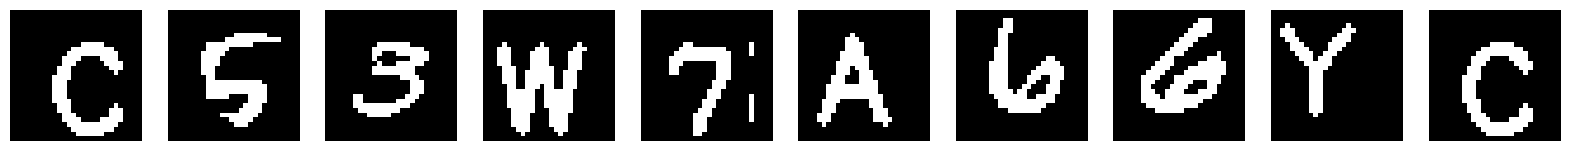

In [5]:
# show first samples
plt.figure(figsize=(20, 2))
for i in range(10):
    img = (images[i].squeeze(0).numpy()*255).astype(np.uint8)
    plt.subplot(1, 10, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

In [5]:
# download weights
!wget http://agentspace.org/download/mnist_cvae8_encoder.pth
!wget http://agentspace.org/download/mnist_cvae8_decoder.pth

--2026-02-26 22:27:21--  http://agentspace.org/download/mnist_cvae8_encoder.pth
Resolving agentspace.org (agentspace.org)... 62.168.101.9
Connecting to agentspace.org (agentspace.org)|62.168.101.9|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.agentspace.org/download/mnist_cvae8_encoder.pth [following]
--2026-02-26 22:27:21--  https://www.agentspace.org/download/mnist_cvae8_encoder.pth
Resolving www.agentspace.org (www.agentspace.org)... 62.168.101.9
Connecting to www.agentspace.org (www.agentspace.org)|62.168.101.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 502147 (490K)
Saving to: ‘mnist_cvae8_encoder.pth.2’

mnist_cvae8_encoder 100%[===================>] 490.38K   620KB/s    in 0.8s    

2026-02-26 22:27:23 (620 KB/s) - ‘mnist_cvae8_encoder.pth.2’ saved [502147/502147]

--2026-02-26 22:27:23--  http://agentspace.org/download/mnist_cvae8_decoder.pth
Resolving agentspace.org (agentspace.org)... 62.16

In [6]:
# load variational autoencoder
encoder = torch.load('mnist_cvae8_encoder.pth', weights_only=False, map_location=device)
decoder = torch.load('mnist_cvae8_decoder.pth', weights_only=False, map_location=device)

In [7]:
encoder.eval()

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (3): ReLU()
  (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU()
  (7): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (8): ReLU()
  (9): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU()
  (12): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU()
  (14): Flatten(start_dim=1, end_dim=-1)
  (15): Linear(in_features=3136, out_features=16, bias=True)
)

In [8]:
decoder.eval()

Sequential(
  (0): Linear(in_features=8, out_features=1568, bias=True)
  (1): ReLU()
  (2): Unflatten(dim=1, unflattened_size=(32, 7, 7))
  (3): ConvTranspose2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (6): ReLU()
  (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (8): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU()
  (10): ConvTranspose2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
  (11): ReLU()
  (12): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (14): Sigmoid()
)

In [9]:
def autoencoder(x, latent_dim=8):
    return decoder(encoder(x)[:,:latent_dim])

In [12]:
recon = autoencoder(images.to(device)).cpu()
diffs = ((images-recon)**2).mean(dim=(1,2,3))
diff = diffs.max()
print(f'diff: {diff.item()}')

diff: 0.2174646258354187


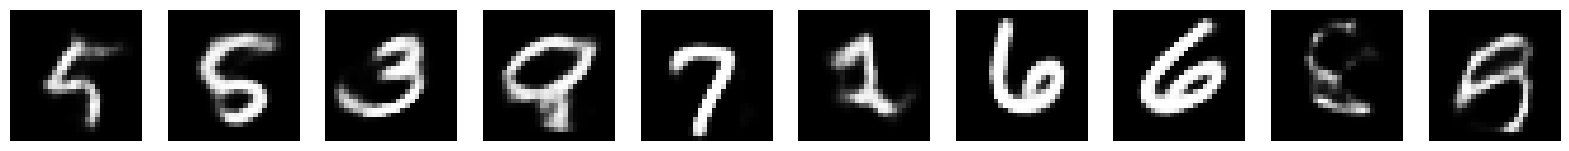

In [19]:
# show first reconstructions
plt.figure(figsize=(20, 2))
for i in range(10):
    img = (recon[i].squeeze(0).detach().numpy()*255).astype(np.uint8)
    plt.subplot(1, 10, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

In [ ]:
# download MNIST dataset
test_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)
test_diffs = []
for x, _ in test_loader:
    x = (x>0.5).float()
    y = autoencoder(x.to(device)).cpu()
    diff = ((x-y)**2).mean(dim=(1,2,3)).detach().cpu()
    test_diffs.append(diff)

In [14]:
print(torch.stack(test_diffs).max())

tensor(0.0911)


In [15]:
# download MNIST dataset
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)
test_diffs = []
for x, _ in test_loader:
    x = (x>0.5).float()
    y = autoencoder(x.to(device)).cpu()
    diff = ((x-y)**2).mean(dim=(1,2,3)).detach().cpu()
    test_diffs.append(diff)

In [16]:
print(torch.stack(test_diffs).max())

tensor(0.0979)


In [14]:
indices = torch.where(diffs > 0.1)[0].numpy().tolist()
print(len(indices))
print(indices)

1729
[0, 3, 5, 8, 9, 14, 18, 31, 32, 38, 39, 44, 49, 54, 55, 56, 61, 62, 77, 79, 89, 91, 92, 96, 97, 101, 106, 110, 115, 123, 124, 126, 136, 138, 140, 148, 157, 168, 176, 182, 190, 207, 217, 224, 231, 232, 235, 237, 249, 253, 276, 279, 281, 285, 288, 291, 310, 312, 313, 314, 316, 319, 322, 327, 339, 351, 359, 360, 366, 378, 381, 383, 385, 388, 390, 393, 394, 395, 399, 403, 417, 431, 436, 441, 444, 462, 463, 469, 476, 489, 491, 519, 541, 542, 543, 544, 548, 549, 557, 561, 564, 568, 572, 580, 581, 585, 586, 602, 603, 604, 611, 616, 629, 638, 641, 642, 643, 654, 657, 659, 660, 663, 664, 665, 666, 668, 669, 672, 673, 676, 677, 694, 697, 699, 700, 711, 712, 715, 716, 722, 726, 733, 760, 772, 781, 783, 786, 790, 793, 795, 797, 800, 802, 808, 813, 826, 827, 829, 831, 836, 839, 847, 848, 861, 867, 886, 887, 888, 896, 897, 898, 899, 902, 908, 919, 929, 942, 943, 947, 965, 968, 976, 982, 986, 993, 994, 995, 1001, 1014, 1019, 1021, 1034, 1041, 1044, 1053, 1063, 1066, 1070, 1076, 1077, 1092, 1093,

In [18]:
letters = images[indices]
print(letters.shape)

torch.Size([1729, 1, 28, 28])


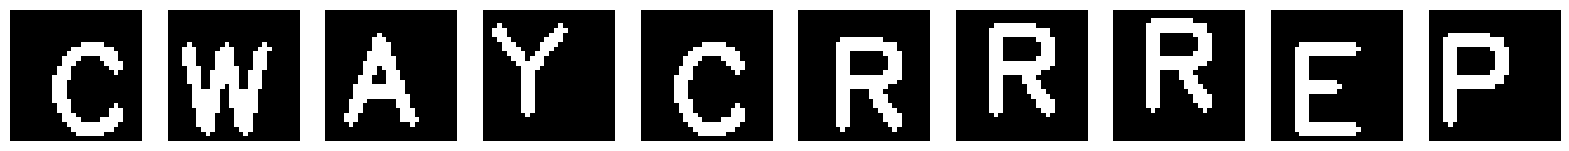

In [20]:
# show first letters
plt.figure(figsize=(20, 2))
for i in range(10):
    img = (letters[i].squeeze(0).detach().numpy()*255).astype(np.uint8)
    plt.subplot(1, 10, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

In [28]:
normals = []
for letter in letters:
    letter = (letter.squeeze(0).numpy()*255).astype(np.uint8)
    x,y,w,h = cv2.boundingRect(letter)
    normal = np.zeros_like(letter)
    normal[0:h,0:w] = letter[y:y+h,x:x+w]
    normals.append(normal)

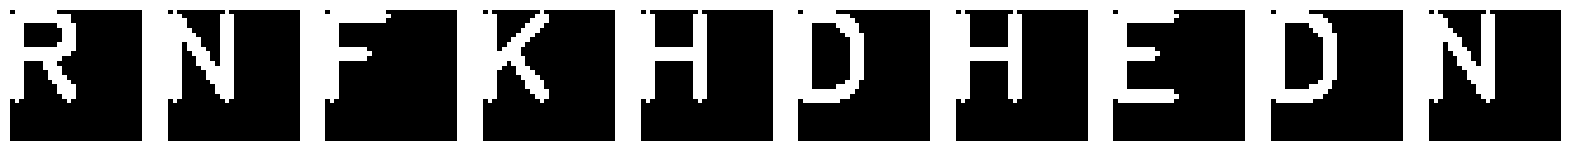

In [31]:
# show first letters
plt.figure(figsize=(20, 2))
ofs=10
for i in range(0,10):
    img = normals[i+ofs]
    plt.subplot(1, 10, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()

In [63]:
repre = {2:'A',0:'C',1:'W',3:'Y',5:'R',8:'E',9:'P',11:'N',12:'F',13:'K',14:'H',15:'D',22:'S',24:'X',25:'B',27:'U',28:'M',32:'L',41:'V',45:'Q',47:'Q',53:'G',80:'J',130:'T'}

In [64]:
s = ""
for i, normal in enumerate(normals):
    found = False
    for k in repre:
        if (normals[k]==normal).min():
            found = True
            print(repre[k],end="")
            s += repre[k]
            break
    if not found:
        print(i)
        plt.imshow(normal, cmap='gray')
        plt.show()
        break

CWAYCRRREPRNFKHDHEDNNFSHXBFUMRWWLXCWRDMSPVYVXQRQSYBFVGUHMGMFRHEDMARQPWSFFUWDWPNVJQALEFUJNNRBLMWAWFKFASRAABGRBGUQDEHSXDAWBXGERJNCGVTMNWTLDGUWBUNQXWMKEQTRPFWRKCNLFLPBNGFMXDNMWJEGPQQWHPMUWQWCUDMPJQRUJBSWKGHQJNMPSFFKNCGXAACHBBMHFWXECBXEFKCQHWEABXFJTFXGPCEQRVFLMAWNWMCDSWRKNRCARBLYPEUCNBXXKNNRYUANRTAVFFBEHFHWTVTPRTETLHXJNHAWFCSXNMHXKHQEKMBUCSCQKVUJFQEEBMUXQPXMLEXXPAWEPHWLWAVHLWGWYERVQCELHNXSMEQPPTTETNGMKEKCNMDFUFQVTWYPNWTCFLKMPLWKMMMKXUNPXGWNACVCRTDSXANNWKQSNNLXHFKWDWNWPGQKNWSYNHPAPXWFRPAWRRGDBMECNPXTMQUCHSBSWXPMWFKGVESKVANHFBARLBFNYQCWBKPNRYDKHQLQUXVHWHFWPBKLBCFSNCWSQKMECFCBAAXMHQFEEBPPMRSLMWBWPKKMMDKYHDWXBKKCWCVLFMMECWWKNXMPBKBRBMBFKWWLBCNVGKGPSXFAMCRQNWQNFWMQQKFXRBRNFJFHNWUHEWPFHDEXXVCTDWXCHYQAPXFCWLXFCVWCVHPNUMNKGNFLKFQRMQGWNWNBRBNXUUSNHNKXWGXRVRKFVERKWWGWRRARPKALADHGFCRBFMRMHVHHVTGVYGCNXBKXMSCMRXRHANNLEQUHEGPGPNKEFUGWDRDMJKHRBREJXMKEHELYWAAALRFQLNGBQAPXPKDQCHKPKKWELUWKHWAKHPMFKRFCSMRUEGJRUVVCWQRXXQWKUWHMGQMMFNDRVXCXBGHRKSWXLSMHAJWGMLNBEEDQRBWLXWFYVVTRNUXAHSTXNRSWWNJBQQFWPMFTGNLNTNENBHPC

In [65]:
s

'CWAYCRRREPRNFKHDHEDNNFSHXBFUMRWWLXCWRDMSPVYVXQRQSYBFVGUHMGMFRHEDMARQPWSFFUWDWPNVJQALEFUJNNRBLMWAWFKFASRAABGRBGUQDEHSXDAWBXGERJNCGVTMNWTLDGUWBUNQXWMKEQTRPFWRKCNLFLPBNGFMXDNMWJEGPQQWHPMUWQWCUDMPJQRUJBSWKGHQJNMPSFFKNCGXAACHBBMHFWXECBXEFKCQHWEABXFJTFXGPCEQRVFLMAWNWMCDSWRKNRCARBLYPEUCNBXXKNNRYUANRTAVFFBEHFHWTVTPRTETLHXJNHAWFCSXNMHXKHQEKMBUCSCQKVUJFQEEBMUXQPXMLEXXPAWEPHWLWAVHLWGWYERVQCELHNXSMEQPPTTETNGMKEKCNMDFUFQVTWYPNWTCFLKMPLWKMMMKXUNPXGWNACVCRTDSXANNWKQSNNLXHFKWDWNWPGQKNWSYNHPAPXWFRPAWRRGDBMECNPXTMQUCHSBSWXPMWFKGVESKVANHFBARLBFNYQCWBKPNRYDKHQLQUXVHWHFWPBKLBCFSNCWSQKMECFCBAAXMHQFEEBPPMRSLMWBWPKKMMDKYHDWXBKKCWCVLFMMECWWKNXMPBKBRBMBFKWWLBCNVGKGPSXFAMCRQNWQNFWMQQKFXRBRNFJFHNWUHEWPFHDEXXVCTDWXCHYQAPXFCWLXFCVWCVHPNUMNKGNFLKFQRMQGWNWNBRBNXUUSNHNKXWGXRVRKFVERKWWGWRRARPKALADHGFCRBFMRMHVHHVTGVYGCNXBKXMSCMRXRHANNLEQUHEGPGPNKEFUGWDRDMJKHRBREJXMKEHELYWAAALRFQLNGBQAPXPKDQCHKPKKWELUWKHWAKHPMFKRFCSMRUEGJRUVVCWQRXXQWKUWHMGQMMFNDRVXCXBGHRKSWXLSMHAJWGMLNBEEDQRBWLXWFYVVTRNUXAHSTXNRSWWNJBQQFWPMFTGNLNTNENBHP